In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
#import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain
from matplotlib import pyplot as plt

### 设置GPU显存按需分配

In [3]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 载入数据

In [144]:
data_train=pd.read_csv('F:/TensorFlow/traindata20230508.csv',header=0,encoding='utf_8')
data_train.info()
data_train.ClassName.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24660 entries, 0 to 24659
Columns: 257 entries, ClassName to Wgs84Y
dtypes: float64(26), int64(230), object(1)
memory usage: 48.4+ MB


array(['荒漠', '膜果麻黄（Ephedra przewalskii）荒漠', '盐爪爪（Kalidium foliatum）荒漠',
       '芨芨草（Achnatherum splendens）草甸', '矮生嵩草（Kobresia humilis）草甸',
       '垂穗披碱草（Elymus nutans）高寒草甸', '高山嵩草（Kobresia pygmaea）草甸',
       '高山薹草（Carex pseudosupina）草原', '紫花针茅（Stipa purpurea）草原',
       '早熟禾、垂穗披碱草高寒草甸', '线叶嵩草（Kobresia capillifolia）草甸',
       '金露梅（Potentilla fruticosa）灌丛', '鹅绒委陵菜（Potentilla anserina）高寒草甸',
       '垫状金露梅（Potentilla fruticosa var. pumila）灌丛',
       '藏北嵩草（Kobresia littledalei）沼泽草甸', '细叶嵩草（Kobresia filifolia）草甸',
       '扇穗茅（Littledalea racemosa）高寒草原',
       '藏嵩草（Kobresia vchaenoides=Kobresia tibetica）沼泽草甸',
       '青藏薹草（Carex moorcroftii）高寒草原', '嵩草（Kobresia spp.）草甸',
       '冰草（Agropyron cristatum）草原', '短花针茅（Stipa breviflora）荒漠草原',
       '芨芨草（Achnatherum splendens）草原', '赖草（Leymus secalinus）草甸',
       '长芒草（Stipa bungeana）草原', '沙生针茅（Stipa glareosa）荒漠草原',
       '华扁穗草（Blysmus sinocompressus）沼泽化草甸', '羊茅（Festuca ovina）杂类草草甸',
       '糙喙薹草（Carex scabrirostris）草甸', '小叶金露梅（Potentilla parvifo

In [145]:
pd.set_option('display.max_rows', None)
print(data_train['ClassName'].value_counts())

高山嵩草（Kobresia pygmaea）草甸                                                     5561
紫花针茅（Stipa purpurea）草原                                                       2067
矮生嵩草（Kobresia humilis）草甸                                                     1381
垂穗披碱草（Elymus nutans）高寒草甸                                                     1112
线叶嵩草（Kobresia capillifolia）草甸                                                 458
藏嵩草（Kobresia vchaenoides=Kobresia tibetica）沼泽草甸                               451
青藏薹草（Carex moorcroftii）高寒草原                                                   441
长芒草（Stipa bungeana）草原                                                         372
藏北嵩草（Kobresia littledalei）沼泽草甸                                                317
细叶早熟禾（Poa pratensis subsp. angustifolia）草甸草原                                  317
芨芨草（Achnatherum splendens）草原                                                  282
圆穗蓼（Polygonum macrophyllum）、珠芽蓼（Polygonum viviparum）高寒草甸                      266
沙生风毛菊（Saussurea 

In [146]:
data_train.head()

,ClassName,num,AET1901,AET1902,AET1903,AET1904,AET1905,AET1906,AET1907,AET1908,...,SR190829B7,SR190930B1,SR190930B2,SR190930B3,SR190930B4,SR190930B5,SR190930B6,SR190930B7,Wgs84X,Wgs84Y
0,荒漠,0,0,0,0,569,641,172,909,500,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103636,28.158935
1,荒漠,0,0,0,0,569,641,172,909,500,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103628,28.159233
2,荒漠,0,0,0,0,766,716,215,953,617,...,1790,1527,3059,1231,2011,3589,3697,3268,87.828855,28.327443
3,荒漠,0,0,0,0,56,1009,417,408,576,...,1717,1254,2300,931,1392,2789,2715,2324,83.346677,30.124012
4,荒漠,0,0,0,0,112,1093,358,224,233,...,980,828,1290,556,838,1670,1533,1175,84.919036,29.596544


In [147]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 切分数据集（已经提前切分的话不用此部分）

In [148]:
split_index = int(len(data_all)*0.7)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7398 entries, 12508 to 13991
Columns: 257 entries, ClassName to Wgs84Y
dtypes: float64(26), int64(230), object(1)
memory usage: 14.6+ MB


### 切分成三份时使用下方代码块

In [8]:
split_index = int(len(data_test)*0.6)
data_tt = data_test.iloc[:split_index]
data_validation = data_test.iloc[split_index:]

test_x = data_tt.iloc[:,7:]
test_y = data_tt.loc[:, ['Value']] 

validation_x = data_validation.iloc[:,7:]
validation_y = data_validation.loc[:, ['Value']]  

train_x = data_train.iloc[:,7:]
train_y = data_train.loc[:, ['Value']]  

validation_x.head(), validation_y.head()

KeyError: "None of [Index(['Value'], dtype='object')] are in the [columns]"

### 切分成两份时使用下方代码块

In [149]:
#train_x = data_train.iloc[:,data_train.columns.str.contains("SR")]
#train_x = data_train.iloc[:,~ data_train.columns.str.contains('ClassName|num|SR')]
train_x = data_train.iloc[:,8:]
train_y = data_train.loc[:, ['num']] 

#test_x = data_test.iloc[:,data_train.columns.str.contains("SR")]
#test_x = data_test.iloc[:,~ data_test.columns.str.contains('ClassName|num|SR')]
test_x = data_test.iloc[:,8:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(       AET1907  AET1908  AET1909  AET1910  AET1911  AET1912  CI20170011  \
 1701      1007      778      764      189        0        0         797   
 4603      1034      946      720      197        0        0         704   
 17277     1013      917      714       74        0        0         889   
 5540      1016      968      721       20        0        0         832   
 13950      252      209       80       49        0        0         907   
 
        CI20170571  CI20171051  CI20171531  ...  SR190829B7  SR190930B1  \
 1701          890         761         783  ...         621        1023   
 4603          878         788         761  ...         645         736   
 17277         955         822         866  ...        1004         845   
 5540          758         820         746  ...        1141         593   
 13950         918         938         905  ...        3002        2231   
 
        SR190930B2  SR190930B3  SR190930B4  SR190930B5  SR190930B6  SR190930B7  \
 1701   

### 类别数量

In [150]:
num_classes = data_train['ClassName'].nunique()
print(num_classes)

140


### 不测试时使用全部数据训练

In [32]:
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

In [33]:
train_x.head()

,AET1901,AET1902,AET1903,AET1904,AET1905,AET1906,AET1907,AET1908,AET1909,AET1910,...,SR190829B7,SR190930B1,SR190930B2,SR190930B3,SR190930B4,SR190930B5,SR190930B6,SR190930B7,Wgs84X,Wgs84Y
0,0,0,0,569,641,172,909,500,590,198,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103636,28.158935
1,0,0,0,569,641,172,909,500,590,198,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103628,28.159233
2,0,0,0,766,716,215,953,617,790,194,...,1790,1527,3059,1231,2011,3589,3697,3268,87.828855,28.327443
3,0,0,0,56,1009,417,408,576,238,101,...,1717,1254,2300,931,1392,2789,2715,2324,83.346677,30.124012
4,0,0,0,112,1093,358,224,233,296,271,...,980,828,1290,556,838,1670,1533,1175,84.919036,29.596544


### 顺序编码转独热编码

In [151]:
train_y = tf.keras.utils.to_categorical(train_y)

In [22]:
validation_y = tf.keras.utils.to_categorical(validation_y)#切分成三份时使用本行，注意test_y不能转为独热！

NameError: name 'validation_y' is not defined

In [152]:
train_x.head()
train_y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

### 定义损失函数为Focal Loss

In [160]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [162]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4096,input_dim=len(train_x.columns)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(64,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))#不懂为啥对不上非要+1
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.1, patience=20, mode='auto')
model.compile(loss=multi_category_focal_loss2, metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()

TypeError: float() argument must be a string or a number, not 'Tensor'

### 开始训练

In [155]:
e = 200
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=32,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Epoch 1/200
17262/17262 [==============================] - 5s 313us/sample - loss: 4.0088 - acc: 0.1912
Epoch 2/200
17262/17262 [==============================] - 4s 240us/sample - loss: 3.5716 - acc: 0.2248
Epoch 3/200
17262/17262 [==============================] - 4s 242us/sample - loss: 3.3017 - acc: 0.2441
Epoch 4/200
17262/17262 [==============================] - 4s 239us/sample - loss: 3.0861 - acc: 0.2671
Epoch 5/200
17262/17262 [==============================] - 4s 236us/sample - loss: 2.9086 - acc: 0.2875
Epoch 6/200
17262/17262 [==============================] - 4s 236us/sample - loss: 2.7666 - acc: 0.3056
Epoch 7/200
17262/17262 [==============================] - 4s 239us/sample - loss: 2.6493 - acc: 0.3256
Epoch 8/200
17262/17262 [==============================] - 4s 240us/sample - loss: 2.5288 - acc: 0.3438
Epoch 9/200
17262/17262 [==============================] - 4s 239us/sample - loss: 2.4213 - acc: 0.3643
Epoch 10/200
17262/17262 [==============================] - 4s 2

17262/17262 [==============================] - 4s 236us/sample - loss: 0.7431 - acc: 0.7505
Epoch 80/200
17262/17262 [==============================] - 4s 237us/sample - loss: 0.7350 - acc: 0.7608
Epoch 81/200
17262/17262 [==============================] - 4s 235us/sample - loss: 0.7175 - acc: 0.7625
Epoch 82/200
17262/17262 [==============================] - 4s 238us/sample - loss: 0.7110 - acc: 0.7595
Epoch 83/200
17262/17262 [==============================] - 4s 240us/sample - loss: 0.7040 - acc: 0.7660
Epoch 84/200
17262/17262 [==============================] - 4s 237us/sample - loss: 0.6999 - acc: 0.7659
Epoch 85/200
17262/17262 [==============================] - 4s 238us/sample - loss: 0.7225 - acc: 0.7639
Epoch 86/200
17262/17262 [==============================] - 4s 240us/sample - loss: 0.6971 - acc: 0.7664
Epoch 87/200
17262/17262 [==============================] - 4s 239us/sample - loss: 0.6878 - acc: 0.7682
Epoch 88/200
17262/17262 [==============================] - 4s 237us

17262/17262 [==============================] - 4s 236us/sample - loss: 0.5084 - acc: 0.8119
Epoch 157/200
17262/17262 [==============================] - 4s 239us/sample - loss: 0.5173 - acc: 0.8074
Epoch 158/200
17262/17262 [==============================] - 4s 238us/sample - loss: 0.5162 - acc: 0.8094
Epoch 159/200
17262/17262 [==============================] - 4s 240us/sample - loss: 0.5203 - acc: 0.8084
Epoch 160/200
17262/17262 [==============================] - 4s 237us/sample - loss: 0.5062 - acc: 0.8105
Epoch 161/200
17262/17262 [==============================] - 4s 236us/sample - loss: 0.5011 - acc: 0.8162
Epoch 162/200
17262/17262 [==============================] - 4s 237us/sample - loss: 0.4950 - acc: 0.8139
Epoch 163/200
17262/17262 [==============================] - 4s 238us/sample - loss: 0.5112 - acc: 0.8113
Epoch 164/200
17262/17262 [==============================] - 4s 238us/sample - loss: 0.4965 - acc: 0.8135
Epoch 165/200
17262/17262 [==============================] -

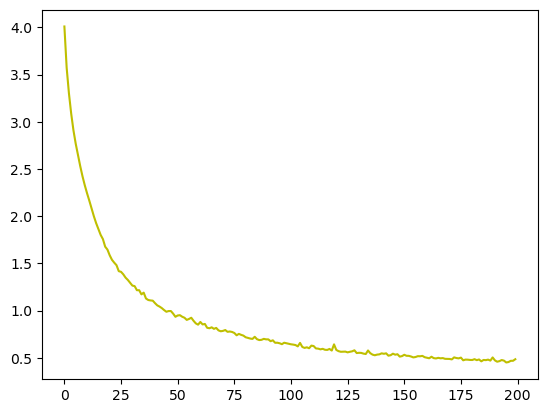

In [156]:
plt.plot(range(200),history.history.get('loss'),color =  'y')

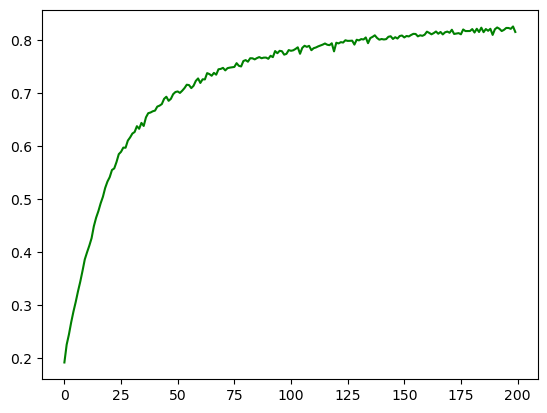

In [157]:
plt.plot(range(200),history.history.get('acc'),color =  'g')

### 载入测试数据（上面的代码里切分过数据集的话不用此部分）

In [90]:
data_test=pd.read_csv('./testdata20200920.csv',header=0,encoding='gb2312')
data_test.info()
data_test.num.unique()
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_test))
# 用生成的乱的索引就能将其打乱了
data_test = data_test.iloc[index ,:]
test_x = data_test.iloc[:,8:]
test_y = data_test.loc[:, ['num']].values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Columns: 260 entries, FID to Y
dtypes: float64(26), int64(231), object(3)
memory usage: 830.9+ KB


### 计算准确率

In [158]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

7398/7398 [==============================] - 1s 116us/sample
准确率： num    0.656258
dtype: float64


### 各类别准确率

In [35]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

TypeError: 'numpy.int64' object is not iterable

### 出结果

In [41]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk.iloc[:,:-1],verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20220122_p1.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/testdata20200806_p1.csv',encoding='gb2312')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 35us/sample
1
100000/100000 [==============================] - 3s 34us/sample
2
100000/100000 [==============================] - 3s 34us/sample
3
100000/100000 [==============================] - 4s 36us/sample
4
100000/100000 [==============================] - 4s 35us/sample
5
100000/100000 [==============================] - 3s 34us/sample
6
100000/100000 [==============================] - 3s 34us/sample
7
100000/100000 [==============================] - 3s 34us/sample
8
100000/100000 [==============================] - 4s 35us/sample
9
100000/100000 [==============================] - 3s 35us/sample
10
100000/100000 [==============================] - 3s 35us/sample
11
100000/100000 [==============================] - 3s 34us/sample
12
100000/100000 [==============================] - 3s 34us/sample
13
100000/100000 [==============================] - 3s 35us/sample
14
100000/100000 [==============================] - 3s 35us/sample
15
10

In [42]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk.iloc[:,:-1],verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20220122_p2.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/testdata20200806_p2.csv',encoding='gb2312')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 33us/sample
1
100000/100000 [==============================] - 3s 35us/sample
2
100000/100000 [==============================] - 4s 36us/sample
3
100000/100000 [==============================] - 3s 35us/sample
4
100000/100000 [==============================] - 4s 37us/sample
5
100000/100000 [==============================] - 4s 35us/sample
6
100000/100000 [==============================] - 3s 35us/sample
7
100000/100000 [==============================] - 4s 35us/sample
8
100000/100000 [==============================] - 4s 36us/sample
9
100000/100000 [==============================] - 4s 35us/sample
10
100000/100000 [==============================] - 3s 35us/sample
11
100000/100000 [==============================] - 4s 35us/sample
12
100000/100000 [==============================] - 3s 35us/sample
13
100000/100000 [==============================] - 3s 34us/sample
14
100000/100000 [==============================] - 3s 34us/sample
15
10

In [43]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk.iloc[:,:-1],verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20220122_p3.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/testdata20200806_p3.csv',encoding='gb2312')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 36us/sample
1
100000/100000 [==============================] - 4s 36us/sample
2
100000/100000 [==============================] - 3s 34us/sample
3
100000/100000 [==============================] - 3s 34us/sample
4
100000/100000 [==============================] - 3s 34us/sample
5
100000/100000 [==============================] - 3s 35us/sample
6
100000/100000 [==============================] - 4s 35us/sample
7
100000/100000 [==============================] - 4s 36us/sample
8
100000/100000 [==============================] - 4s 35us/sample
9
100000/100000 [==============================] - 3s 35us/sample
10
100000/100000 [==============================] - 3s 34us/sample
11
100000/100000 [==============================] - 3s 35us/sample
12
100000/100000 [==============================] - 3s 34us/sample
13
100000/100000 [==============================] - 3s 34us/sample
14
100000/100000 [==============================] - 3s 34us/sample
15
10

122
100000/100000 [==============================] - 3s 34us/sample
123
100000/100000 [==============================] - 3s 34us/sample
124
100000/100000 [==============================] - 4s 35us/sample
125
100000/100000 [==============================] - 3s 35us/sample
126
100000/100000 [==============================] - 4s 35us/sample
127
100000/100000 [==============================] - 4s 35us/sample
128
100000/100000 [==============================] - 3s 34us/sample
129
100000/100000 [==============================] - 3s 34us/sample
130
100000/100000 [==============================] - 3s 34us/sample
131
100000/100000 [==============================] - 3s 34us/sample
132
100000/100000 [==============================] - 3s 34us/sample
133
100000/100000 [==============================] - 4s 36us/sample
134
100000/100000 [==============================] - 3s 34us/sample
135
100000/100000 [==============================] - 3s 34us/sample
136
100000/100000 [=============================